#  Practica N° 3: Perceptrón simples
### **UNIDAD: 3**
### **Carrera:** Tecnicatura Superior en Ciencia de Datos e IA
### **Institución:** IFTS 33 - UOCRA
### **Profesor:** Andres Allievi
## **Alumna**: Chino Priscila
---

# Taller Práctico: Clasificación de Riesgo Crediticio con Perceptrón
## Contexto del Problema
Una entidad financiera desea automatizar la aprobación de créditos pre-aprobados.

Se cuenta con dos variables de entrada:

* Puntaje Crediticio (Normalizado de 0 a 1).

* Ratio de Ahorro (Dinero ahorrado vs ingresos anuales).

El objetivo es entrenar un Perceptrón Simple en Keras para que aprenda la frontera de decisión que separa a los clientes de "Bajo Riesgo" (Clase 1) de los de "Alto Riesgo" (Clase 0).

**¿Qué es un puntaje crediticio?**

Es como una calificación que te dan las entidades financieras para medir qué tan confiable sos para devolver un préstamo. Si has pagado tus deudas a tiempo en el pasado, tu puntaje es más alto.

**¿Qué es un ratio de ahorro?**
La proporción de tus ingresos que estás guardando en lugar de gastar. Por ejemplo, si de cada 100 pesos que ganás, ahorrás 20 pesos, tu ratio de ahorro es del 20%.

## Paso 1: Preparación del Entorno
Cargamos las librerías necesarias y generamos un dataset sintético que represente este escenario.

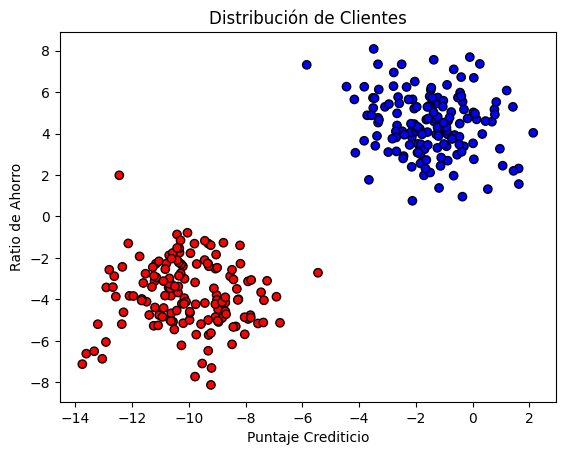

In [63]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs

# Generamos datos: 300 clientes con 2 características
X, y = make_blobs(n_samples=300, centers=2, n_features=2, cluster_std=1.5, random_state=1)

# n_samples → cantidad de clientes.
# Centers → dos caracteristicas, por las dos salidas (Bajo Riesgo" o"Alto Riesgo").
# n_features → las dos entradas del modelo (puntaje y ratio).
# cluster_std → que tan dirpersos esten los datos. Asi el modelo tenga dificultad media.
# random_state → al ejecutar el codigo se generen los mismos datos.

# Visualización inicial
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.xlabel("Puntaje Crediticio")
plt.ylabel("Ratio de Ahorro")
plt.title("Distribución de Clientes")
plt.show()

## Paso 2: Definición de la Arquitectura (Misión del Alumno)
Debes definir un modelo secuencial que represente un Perceptrón Simple. Recuerda que para una clasificación binaria, la salida debe pasar por una función que comprima el valor entre 0 y 1.

**Guía Técnica:**

* Usa una capa Dense.

* Como es un Perceptrón de una sola capa, units debe ser igual a 1.

* El input_shape debe coincidir con la cantidad de variables de entrada (2).

In [64]:
# --- COMPLETA EL CÓDIGO AQUÍ ---
model = Sequential([
    Dense(units=1, input_shape=(2,), activation='sigmoid')
])

#model → contenedor principal
#sequntial → asi indico que voy a agregar capas una detrás de otra.
#dense() → agrega una capa densa a ese modelo secuencial.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Paso 3: Compilación del Sistema
Para que el modelo aprenda, debemos definir el Optimizador (que gestiona la Tasa de Aprendizaje) y la Función de Pérdida (que mide el error).

**Ayuda Sugerida:**

* Para clasificación binaria, la pérdida estándar es binary_crossentropy.

* Experimenta con diferentes valores en learning_rate (prueba con 0.01, 0.1 y 0.5).

In [65]:
# --- COMPLETA EL CÓDIGO AQUÍ --- COMO LA RED VA A APRENDER
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
# Define el optimizer usando tf.keras.optimizers.SGD y la loss adecuada.
#accuracy → que tan bien aprende en cada epoca
#learning_rate → el tamaño y velocidad de los pasos a medida que aprende.
               # Con pasos largos, salta mas rapido pero puede pasarse. Es mejor a menos pasos
# ------------------------------
# binary_crossentropy → clasifica en las dos opciones posibles y mide qué tan lejos o cerca esta de la respuesta correcta, o sea, el error.

## Paso 4: Entrenamiento y Regularización
Es momento de ajustar los pesos. Vamos a entrenar el modelo, pero esta vez, presta atención a cómo el número de épocas afecta el resultado.

**Instrucciones:**

* Ejecuta el método .fit().

* Prueba configurar el entrenamiento con 50 épocas.

In [66]:
# --- COMPLETA EL CÓDIGO AQUÍ ---
history = model.fit(X, y, epochs=50, verbose=1)

# ------------------------------
# epochs=50 → asi el modelo revisara el dataset completo 50 veces.
# verbose=0 → ver informacion de cada epoca

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6367 - loss: 0.8207  
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9633 - loss: 0.1840 
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9967 - loss: 0.1006 
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9967 - loss: 0.0750 
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9967 - loss: 0.0628 
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9967 - loss: 0.0557 
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9967 - loss: 0.0508 
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9967 - loss: 0.0472 
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9967 - loss: 0.0445 
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9967 - loss: 0.0422 
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9967 - loss: 0.0404 
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy:

### learning_rate = 0.01

1024/1024 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


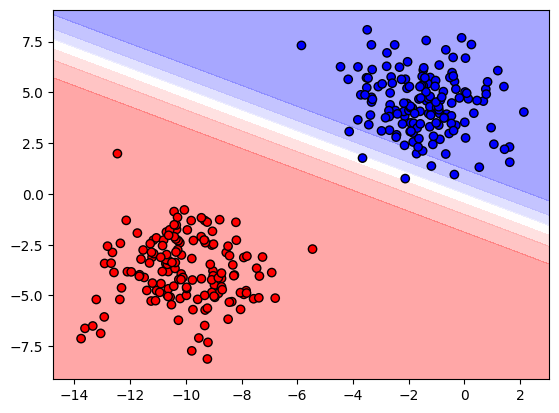

In [55]:
# -------- CON VALOR 0.01 EN learning_rate ----------
def plot_frontier(X, y, model): # como el modelo separa las diferentes clases.
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='bwr')
    plt.show()

plot_frontier(X, y, model)

### learning_rate = 0.1

1024/1024 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


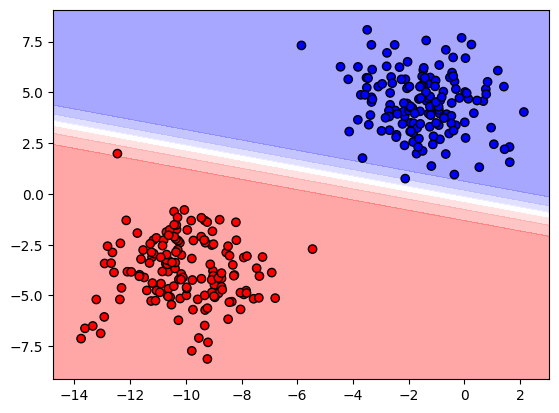

In [18]:
# -------- CON VALOR 0.1 EN learning_rate ----------
def plot_frontier(X, y, model): # como el modelo separa las diferentes clases.
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='bwr')
    plt.show()

plot_frontier(X, y, model)

### learning_rate = 0.5

1024/1024 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


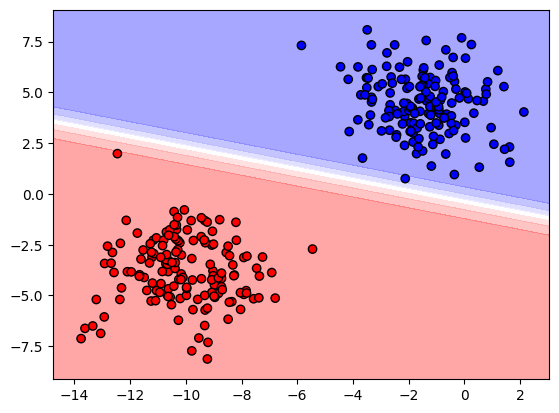

In [21]:
# -------- CON VALOR 0.5 EN learning_rate ----------
def plot_frontier(X, y, model): # como el modelo separa las diferentes clases.
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='bwr')
    plt.show()

plot_frontier(X, y, model)

## Paso 5: Evaluación de Resultados
Una vez entrenado, utilizaremos el siguiente bloque para visualizar la Frontera de Decisión que tu modelo ha construido.

1024/1024 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


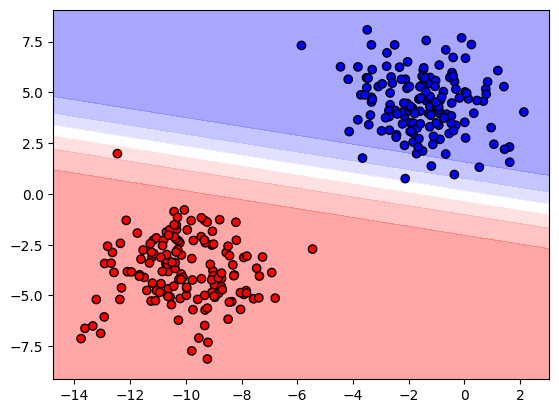

In [67]:
def plot_frontier(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='bwr')
    plt.show()

plot_frontier(X, y, model)

## Desafíos Extra
**Impacto del Sesgo:** Si imprimes los pesos del modelo con model.get_weights(), ¿cuál es el valor del Bias?

¿Qué pasaría si fuera cero?

**Regularización:** Regresa al Paso 2 e intenta agregar kernel_regularizer='l2' dentro de la capa Dense.

¿Notas algún cambio en la suavidad de la frontera o en el valor de los pesos?

**No Linealidad:** Cambia el generador de datos por make_moons(n_samples=300, noise=0.1).

¿Es capaz el Perceptrón de una sola capa de separar estos datos? Justifica basándote en la teoría de Separabilidad Lineal.

### 1: Impacto del Sesgo

In [37]:
# --- 1: Impacto del Sesgo --- QUE APRENDIO LA NEURONA

# Le pedimos a la red que nos muestre sus "fuerzas de conexión" (pesos) y su ajuste (bias)
weights, bias = model.get_weights()
print(f"Peso para Puntaje Crediticio (w1): {weights[0][0]:.4f}")
print(f"Peso para Ratio de Ahorro (w2): {weights[1][0]:.4f}")
print(f"Sesgo o Ajuste (bias): {bias[0]:.4f}")

# pesos →  indica cuanto influye cada variable en la decisión:
#   - Si el peso es negativo, esa caracteristica resta puntos a la probabilidad de "sí prestar".
#   - Si el peso es positivo, suma puntos a esa probabilidad.
# bias →  ajuste fino: desplaza la frontera de decisión hacia arriba o abajo.
#   - Si el bias es negativo, la frontera se corre hacia abajo (más dificil aprobar).
#   - Si fuera cero, la frontera pasaría por el origen y todos los datos se interpretarian igual


Peso para Puntaje Crediticio (w1): -0.4104
Peso para Ratio de Ahorro (w2): -1.3222
Sesgo o Ajuste (bias): -0.2215


### 2: Regularización

In [39]:
# --- 2: Regularización --- PARA QUE EL MODELO NO SEA "tan extremo"
from tensorflow.keras import regularizers

model = Sequential([
    # Agrego kernel_regularizer a la capa Dense
    Dense(units=1, input_shape=(2,), activation='sigmoid',
          kernel_regularizer=regularizers.l2(0.01))
])

# Cuando ejecuto, los valores de los pesos tienden a ser más pequeños.
# Al observar, la frontera de decisión (la línea) queda un poco más alejada de los puntos porque busca un margen más seguro.

### 3: No Linealidad

In [61]:
# --- 3: No Linealidad --- REEMPLAZA EL PASO 4

from sklearn.datasets import make_moons

# Generar datos no lineales
X, y = make_moons(n_samples=300, noise=0.1, random_state=42)

# Normalización rápida para que Keras trabaje mejor
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(X)

111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


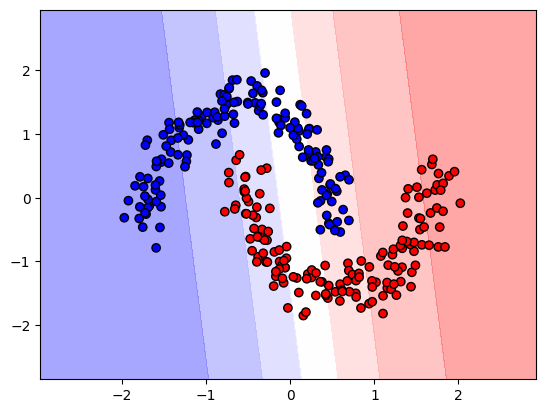

In [62]:
# PaASO 5: Evaluación de Resultados
def plot_frontier(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='bwr')
    plt.show()

plot_frontier(X, y, model)

Resultado: El Perceptrón intenta trazar una linea recta, pero falla terriblemente al intentar separar las dos lunas. Observo que muchos puntos terminan mezclados, rojos con azules.

NOTA: El Perceptrón Simple es un clasificador lineal. Solo entiende problemas que se resuelven con una línea recta. Como los datos de las "lunas" son no lineales, el modelo llega a su límite técnico.